# Equity champions — feature importance (train-only, clean split)

Champions from `selection_table.csv` — purged inner k-fold + 1SE, global cut **2021-10-06**.
All importance analysis uses **train data only** (post-split). The held-out 30% (post-2021-10-20) is **sealed**.

| Instrument | Group | Champion | AUC | Lower CI | Signal |
|------------|-------|----------|-----|----------|--------|
| es1s | es1s | Logistic | 0.595±0.029 | 0.567 | YES |
| nq1s | nq1s | XGB | 0.570±0.033 | 0.537 | YES |
| fesx1s | fesx1s | RF | 0.496±0.024 | 0.472 | NO |

> **fesx1s** carries no confirmed signal (lower CI < 0.50). Its importance analysis is included for contrast only.
> **es1s** and **nq1s** both clear the 1σ bar with logistic and XGB champions respectively.

---
## Analysis pipeline

The same five-step sequence is applied to each instrument. All computations run on **train data only**;
the sealed 30% test set is never read here and no model is evaluated OOS.

### Step 1 — Feature clustering
Continuous features (excluding hand-assigned groups) are clustered by **Spearman distance** √(1−|ρ|)
with **Ward linkage**. The number of clusters K is chosen by silhouette score over K ∈ [2, 25].
Four groups are hand-assigned by prefix: `f4_` → F4_latent, `f5_` → F5_signal, `f8_` → F8_calendar,
`inst_` → F_instrument (pooled models only). These bypass correlation clustering.

### Step 2 — Cluster-level importance
Three importance signals per cluster, evaluated within **CPCV** (n_groups=6, k=2, embargo=1 %):

- **Clustered MDA** (headline): jointly permute all cluster members with one shared row permutation;
  N=10 repeats averaged; score AUC drop on target instrument's CPCV test slice.
  For pooled models the test slice is filtered to the target instrument before scoring.
- **Tree models** — MDI (train; sum feature_importances_ within cluster) and Group SHAP
  (TreeSHAP, tree_path_dependent, OOS slice).
- **Logistic model** — cluster |coef| sum (sum of |standardised elastic-net coefficients|
  per cluster). MDA permutes the **scaled** data (scaler fitted on outer-train fold).

A cluster is **significant** when its mean MDA drop > 1σ (cross-CPCV std).
**Rank agreement** is assessed via Kendall τ across cluster MDA / MDI / SHAP rankings
(or MDA / Coef for logistic); |τ| > 0.4 is treated as agreement.

### Step 3 — Within-cluster breakdown (top 3 clusters)
For the top 3 clusters by MDA (preferring significant clusters), individual members are ranked
by mean |SHAP| (tree) or mean |coef| (logistic). Single-feature permutation is intentionally
**not used** within a cluster — correlated members would inflate individual scores.

### Step 4 — PCA within top clusters
**PCA** (up to 3 PCs, standardised inputs) on the cluster's train submatrix.
PC1 variance interpretation tier: ≥65 % = single latent dimension; 40–65 % = dominant direction;
<40 % = genuinely multi-dimensional. Loadings reveal which members drive each component.

### Step 5 — Global per-feature view
**Tree**: mean |SHAP| per feature (averaged across CPCV paths), coloured by sign (red = positive,
blue = negative predictive direction). Also reports per-feature MDI.
**Logistic**: mean |standardised coefficient| per feature, coloured by sign.
SHAP direction reflects **model direction**, not necessarily profitable direction — the model may
learn to trade against a feature.


In [1]:
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Image, display

BASE = Path('outputs/importance')

def show(path, width=1100):
    p = Path(path)
    if p.exists():
        display(Image(str(p), width=width))
    else:
        print(f'[missing] {p}')

def load(path):
    p = Path(path)
    if p.exists():
        return pd.read_csv(p)
    print(f'[missing] {p}')
    return pd.DataFrame()

def cluster_summary(inst):
    mem = load(BASE / inst / 'cluster_membership.csv')
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    if mem.empty or mda.empty:
        return pd.DataFrame()
    grp = (
        mem.groupby('cluster')
        .agg(
            n_members=('feature', 'count'),
            dominant_pfx=('f_prefix', lambda x: x.value_counts().index[0]),
            purity=('f_prefix', lambda x: round(x.value_counts().iloc[0] / len(x), 2)),
        )
        .reset_index()
    )
    mda_sub = mda[['cluster', 'mean_drop', 'std_drop', 'significant']].copy()
    return grp.merge(mda_sub, on='cluster', how='left').sort_values('mean_drop', ascending=False)

print('Setup complete. Artifact root:', BASE.resolve())


Setup complete. Artifact root: /Users/harrybrowne/Downloads/Imperial Work/SystematicTrading/stml/src/stml/new_work/outputs/importance


---
## ES1S — champion: `es1s` / Logistic (elastic-net)

**CPCV:** 15 paths · AUC 0.595 ± 0.029 · **SIGNAL** (lower CI 0.567)

**Significant clusters:** C10\_f1, C2\_f2, C8\_f11\_lowfreq\_macro (3 clusters).

> **es1s** uses an **elastic-net logistic** champion. Importance analysis therefore uses:
> **clustered MDA** (permutes scaled data) as the headline; and
> **sum of |standardised coefficients|** per cluster as the cross-check (replaces MDI/SHAP).
>
> Three clusters are significant: **C10\_f1** (f1 mean-reversion; top coef `f1_mr_score_20` 0.088)
> leads, followed by **C2\_f2** (vol/regime; top `hmm_vol_p2_turbulent` 0.102 and
> `hmm_vol_p0_calm` 0.093) and **C8\_f11\_lowfreq\_macro** (rates:
> `f11_ust_10y_5d_change` 0.224 dominates 3-feature cluster).

### Step 1 · Feature clusters


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
15,F5_signal,5,f5_,100%,0.0827,0.0343,True
4,C14_f11,7,f11_,29%,0.0185,0.0550,False
6,C2_f2,16,f2_,44%,0.0122,0.0226,False
7,C3_f11_lowfreq_macro,2,f11_,100%,0.0003,0.0035,False
9,C5_f7,3,f7_,100%,-0.0007,0.0146,False
16,F8_calendar,4,f8_,100%,-0.0009,0.0031,False
0,C10_f1,14,f1_,79%,-0.0026,0.0137,False
8,C4_f11,4,f11_,50%,-0.0027,0.0122,False
13,C9_f11,7,f11_,43%,-0.0029,0.0075,False
11,C7_f11,8,f11_,38%,-0.0032,0.0128,False


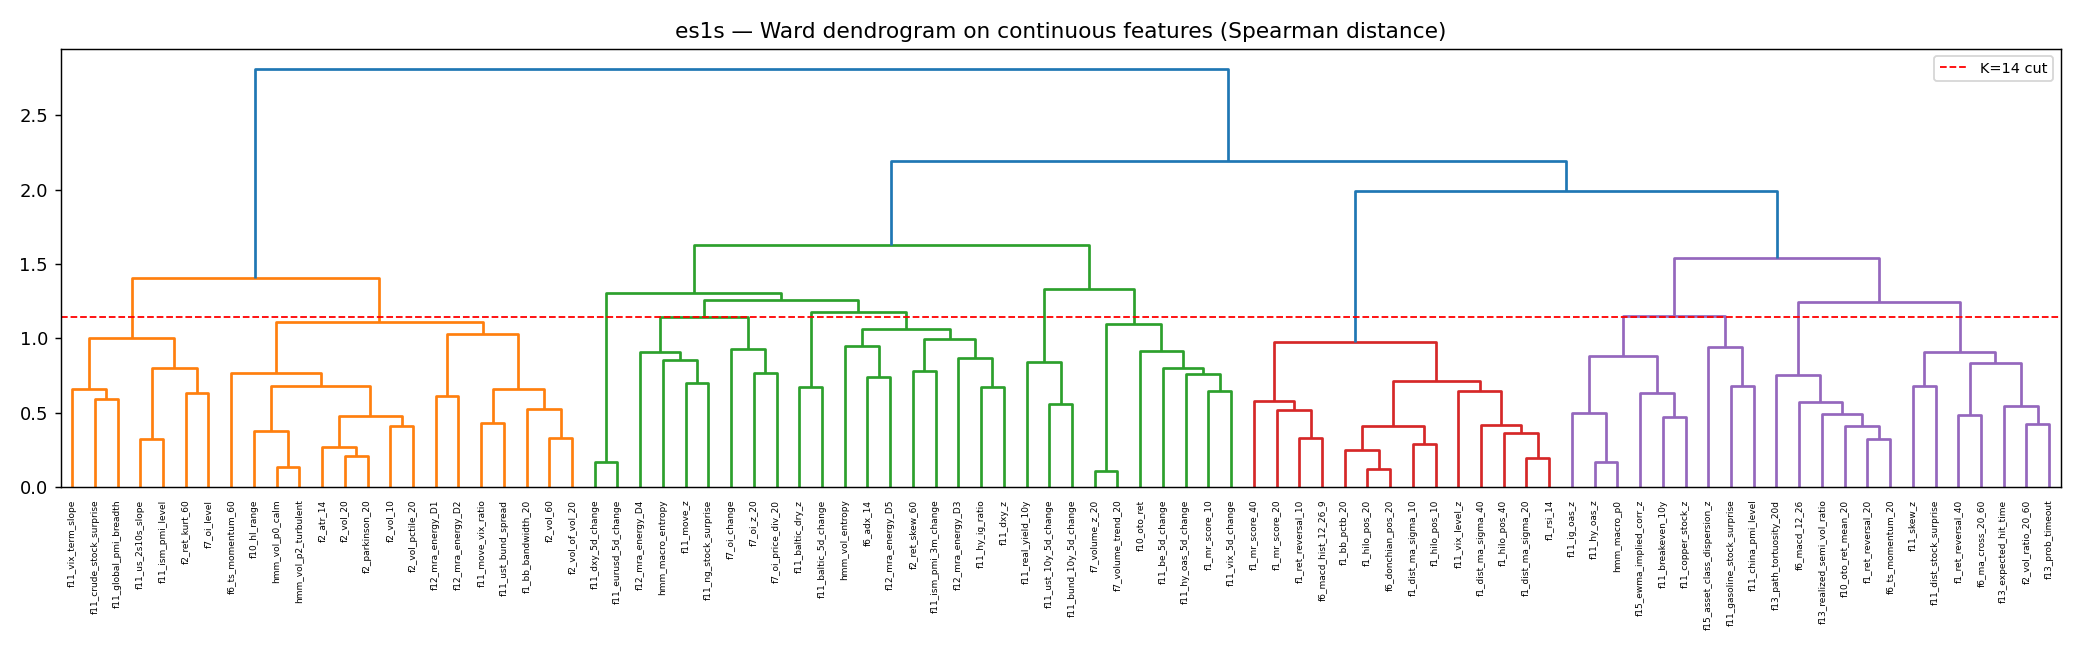

In [2]:
cs = cluster_summary('es1s')
display(
    cs.style
    .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
    .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-0.02, vmax=0.10)
    .set_caption('es1s — cluster summary (K=14 corr + 3 hand-assigned = 17 groups)')
)
show(BASE / 'es1s' / 'dendrogram.png', width=1100)


### Step 2 · Cluster-level importance

Clustered MDA (dark = significant > 1σ, light = inconclusive). Cross-check with MDI and SHAP.
Rank agreement assessed via Kendall τ; |τ| > 0.4 = agree.


In [ ]:
show(BASE / 'es1s' / 'clustered_mda_chart.png', width=1050)
cc = load(BASE / 'es1s' / 'cluster_crosscheck_table.csv')
ra = load(BASE / 'es1s' / 'rank_agreement.csv')
if not cc.empty:
    fmt_cols = {'mda_mean': '{:.4f}'}
    for col in ('coef_sum', 'mdi_sum', 'shap_sum'):
        if col in cc.columns:
            fmt_cols[col] = '{:.4f}'
    display(
        cc.style
        .format(fmt_cols)
        .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-0.05, vmax=0.10)
        .set_caption('es1s — cluster cross-check (MDA · Coef ranks; elastic-net logistic)')
    )
if not ra.empty:
    print('\nKendall τ rank agreement:')
    display(ra.style.format({'kendall_tau': '{:.2f}'}))

### Step 3 · Within-cluster breakdown (top 3 significant clusters)

Members ranked by mean |coef| (elastic-net logistic). PCA on train submatrix.

**C10\_f1** (PC1=77.5%, ≥65% → single latent dim): `f1_mr_score_20` dominates (|coef|=0.088);
cluster spans mean-reversion signals across 10/20/40-bar horizons plus RSI, Bollinger, and donchian.

**C2\_f2** (PC1=63.7%, 40–65% → dominant direction): volatility/vol-regime cluster;
`hmm_vol_p2_turbulent` (0.102) and `hmm_vol_p0_calm` (0.093) are top members,
alongside `f11_move_vix_ratio`, `f11_ust_bund_spread`, and a range of realised-vol features.

**C8\_f11\_lowfreq\_macro** (PC1=69.4%, ≥65% → single latent dim): compact 3-feature rates cluster;
`f11_ust_10y_5d_change` dominates (|coef|=0.224), with bund 10y change and real yield.

In [ ]:
wc = load(BASE / 'es1s' / 'within_cluster_C10_f1.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'es1s | C10_f1 — |coef| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'es1s' / 'within_cluster_C10_f1.png', width=950)

In [ ]:
wc = load(BASE / 'es1s' / 'within_cluster_C2_f2.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'es1s | C2_f2 — |coef| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'es1s' / 'within_cluster_C2_f2.png', width=950)

In [ ]:
wc = load(BASE / 'es1s' / 'within_cluster_C8_f11_lowfreq_macro.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'es1s | C8_f11_lowfreq_macro — |coef| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'es1s' / 'within_cluster_C8_f11_lowfreq_macro.png', width=950)

### Step 5 · Global per-feature coefficient

Mean |standardised elastic-net coefficient| per feature, averaged across 15 CPCV paths.
Red = positive predictive direction (higher feature → higher P(bin=1)), blue = negative.

In [ ]:
gc = load(BASE / 'es1s' / 'global_coef_summary.csv')
if not gc.empty:
    display(
        gc.head(25).style
        .format({'coef_abs': '{:.4f}', 'coef_signed': '{:.4f}'})
        .background_gradient(subset=['coef_abs'], cmap='Blues')
        .set_caption('es1s — top 25 features by mean |standardised coefficient| (logistic, SIGNAL)')
    )
show(BASE / 'es1s' / 'global_coef_chart.png', width=1000)

---
## NQ1S — champion: `nq1s` / XGB

**CPCV:** 15 paths · AUC 0.570 ± 0.033 · **SIGNAL** (lower CI 0.537)

**Significant clusters:** C8\_f11 (MDA 0.026 ± 0.020), C1\_f1 (MDA 0.022 ± 0.020).

> NQ1S retains an XGB champion with confirmed signal. Two clusters clear the 1σ bar:
> **C8\_f11** (macro/credit: copper stocks z-score, breakeven inflation, credit spreads) and
> **C1\_f1** (f1 mean-reversion: short-term reversal, RSI, hi-lo position).
> MDA–SHAP agreement (τ below) validates the ranking direction.

### Step 1 · Feature clusters


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
16,F5_signal,5,f5_,100%,0.1744,0.0736,True
9,C4_f11,5,f11_,40%,0.0627,0.0499,True
13,C8_f11,9,f11_,78%,0.0124,0.0274,False
11,C6_f11,6,f11_,83%,0.0095,0.0195,False
1,C11_f11,7,f11_,57%,0.0063,0.0149,False
2,C12_f11_lowfreq_macro,2,f11_,100%,0.0057,0.0115,False
0,C10_f7,2,f7_,100%,0.0015,0.0050,False
8,C3_f6,6,f6_,33%,0.0012,0.0041,False
14,C9_f11_lowfreq_macro,3,f11_,100%,0.0005,0.0055,False
12,C7_f12,8,f12_,38%,-0.0000,0.0037,False


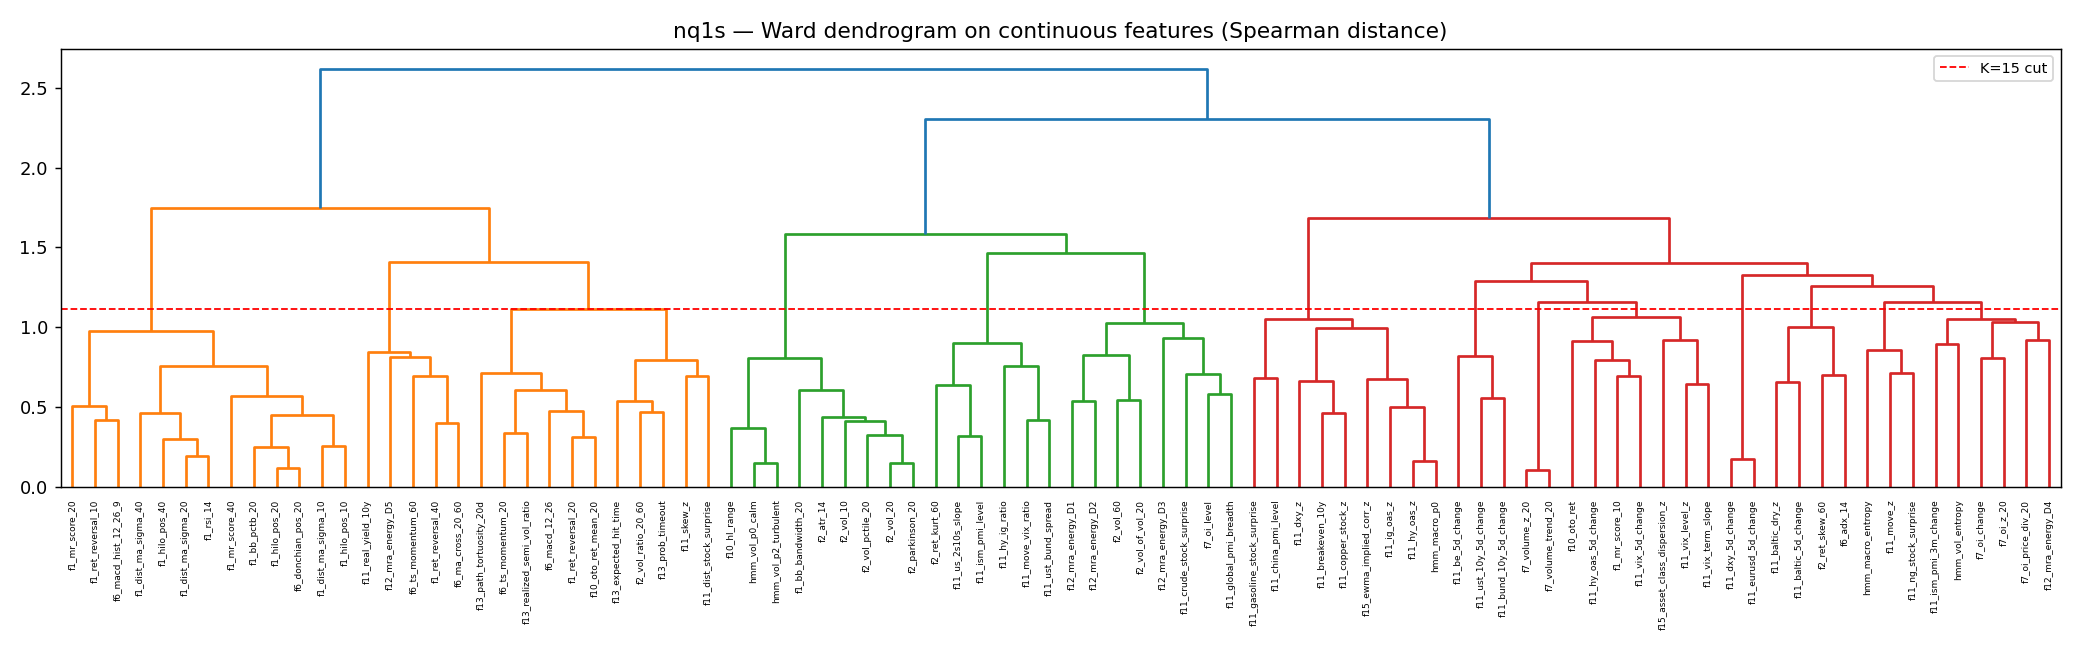

In [8]:
cs = cluster_summary('nq1s')
display(
    cs.style
    .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
    .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-0.02, vmax=0.20)
    .set_caption('nq1s — cluster summary (K=15 corr + 3 hand-assigned = 18 groups)')
)
show(BASE / 'nq1s' / 'dendrogram.png', width=1100)


### Step 2 · Cluster-level importance

Clustered MDA (dark = significant > 1σ). Cross-check with MDI and SHAP.


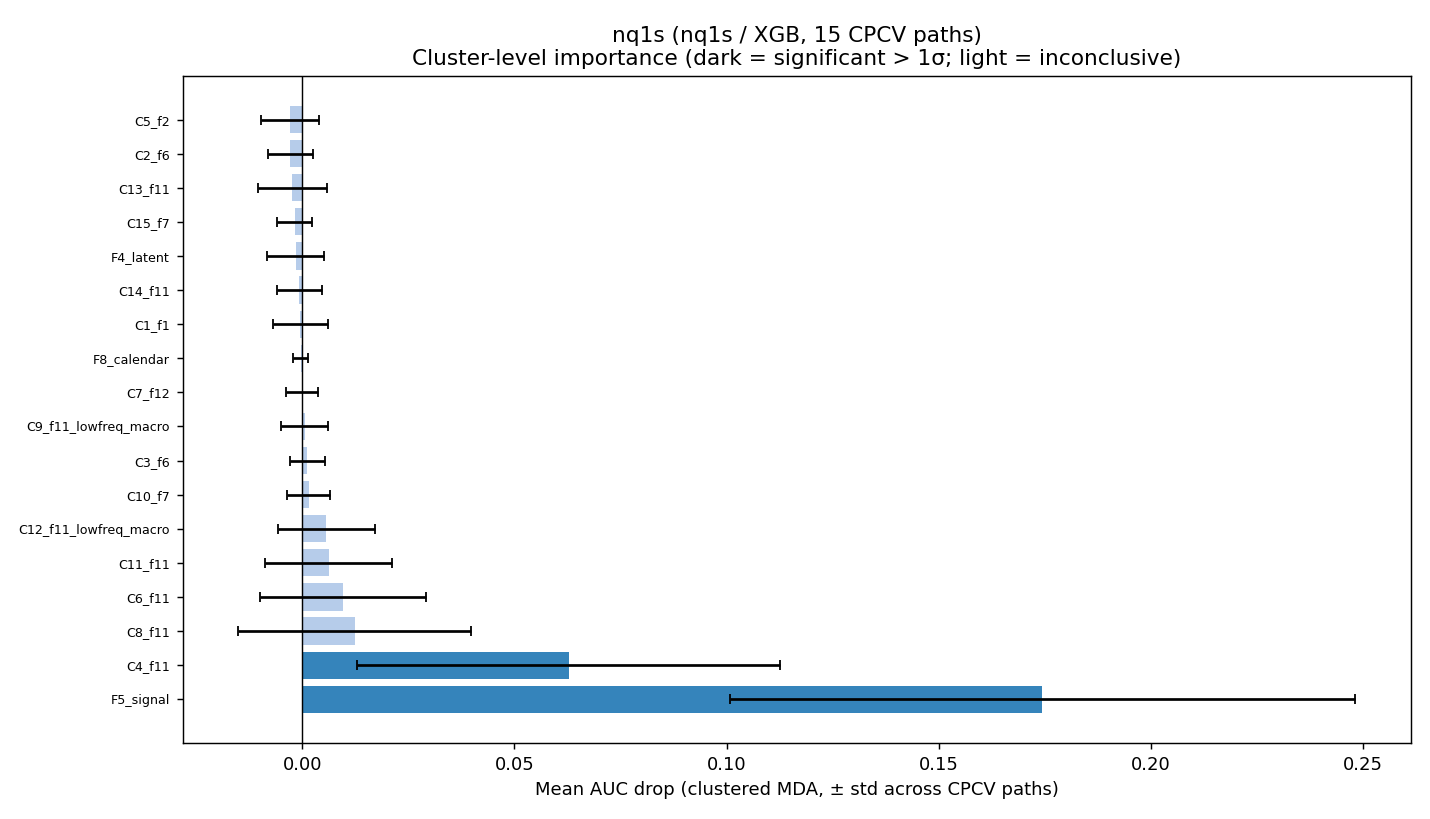

,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,F5_signal,0.1744,1,0.0889,3,0.3044,1,True
1,C4_f11,0.0627,2,0.0743,5,0.0780,3,True
2,C8_f11,0.0124,3,0.1237,1,0.0969,2,False
3,C6_f11,0.0095,4,0.0777,4,0.0622,4,False
4,C11_f11,0.0063,5,0.0651,7,0.0606,5,False
5,C12_f11_lowfreq_macro,0.0057,6,0.0339,14,0.0283,7,False
6,C10_f7,0.0015,7,0.0312,15,0.0105,15,False
7,C3_f6,0.0012,8,0.0446,11,0.0076,17,False
8,C9_f11_lowfreq_macro,0.0005,9,0.0354,13,0.0213,9,False
9,C7_f12,-0.0000,10,0.0625,8,0.0201,10,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.24,False
1,MDA-SHAP,0.49,True
2,MDI-SHAP,0.59,True


In [9]:
show(BASE / 'nq1s' / 'clustered_mda_chart.png', width=1050)
cc = load(BASE / 'nq1s' / 'cluster_crosscheck_table.csv')
ra = load(BASE / 'nq1s' / 'rank_agreement.csv')
if not cc.empty:
    display(
        cc.style
        .format({'mda_mean': '{:.4f}', 'mdi_sum': '{:.4f}', 'shap_sum': '{:.4f}'})
        .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-0.05, vmax=0.20)
        .set_caption('nq1s — cluster cross-check (MDA · MDI · SHAP ranks)')
    )
if not ra.empty:
    print('\nKendall \u03c4 rank agreement:')
    display(ra.style.format({'kendall_tau': '{:.2f}'}))


### Step 3 · Within-cluster breakdown (top 3 by MDA)

Members ranked by mean |SHAP|. PCA on train submatrix.

**C8\_f11** (PC1=59.4%, 40–65% → dominant direction): macro/credit cluster;
`f11_copper_stock_z` leads by SHAP (0.050), followed by `f11_breakeven_10y` (0.013),
`f11_dxy_z`, credit spreads, and `hmm_macro_p0`. PC1 captures a risk-off macro dimension.

**C1\_f1** (PC1=78.6%, ≥65% → single latent dim): f1 mean-reversion cluster;
`f1_ret_reversal_10` tops by SHAP (0.010), alongside `f1_hilo_pos_40` and `f1_rsi_14`.
Cohesive: one reversal latent factor across horizons.

**C5\_f2** (MDA 0.014, not significant): vol/momentum cross cluster; shown for completeness.

In [ ]:
wc = load(BASE / 'nq1s' / 'within_cluster_C8_f11.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'nq1s | C8_f11 — SHAP ranking + PC1 loadings  ({label})')
    )
show(BASE / 'nq1s' / 'within_cluster_C8_f11.png', width=950)

In [ ]:
wc = load(BASE / 'nq1s' / 'within_cluster_C1_f1.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'nq1s | C1_f1 — SHAP ranking + PC1 loadings  ({label})')
    )
show(BASE / 'nq1s' / 'within_cluster_C1_f1.png', width=950)

In [ ]:
wc = load(BASE / 'nq1s' / 'within_cluster_C5_f2.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'nq1s | C5_f2 — SHAP ranking + PC1 loadings  ({label})  [not significant]')
    )
show(BASE / 'nq1s' / 'within_cluster_C5_f2.png', width=950)

### Step 5 · Global per-feature SHAP

Mean |SHAP| per feature, averaged across 15 CPCV paths on nq1s. Red = positive, blue = negative.


,feature,shap_magnitude,shap_signed,mdi
0,f5_signal,0.2978,0.0820,0.0636
1,f11_dist_stock_surprise,0.0609,-0.0118,0.0365
2,f11_copper_stock_z,0.0390,0.0111,0.0252
3,f11_vix_5d_change,0.0333,0.0099,0.0256
4,f11_gasoline_stock_surprise,0.0254,-0.0007,0.0216
5,f11_move_vix_ratio,0.0246,-0.0084,0.0204
6,f11_dxy_5d_change,0.0230,-0.0025,0.0192
7,f11_be_5d_change,0.0174,0.0071,0.0201
8,f11_hy_ig_ratio,0.0151,0.0020,0.0128
9,f11_breakeven_10y,0.0132,0.0018,0.0185


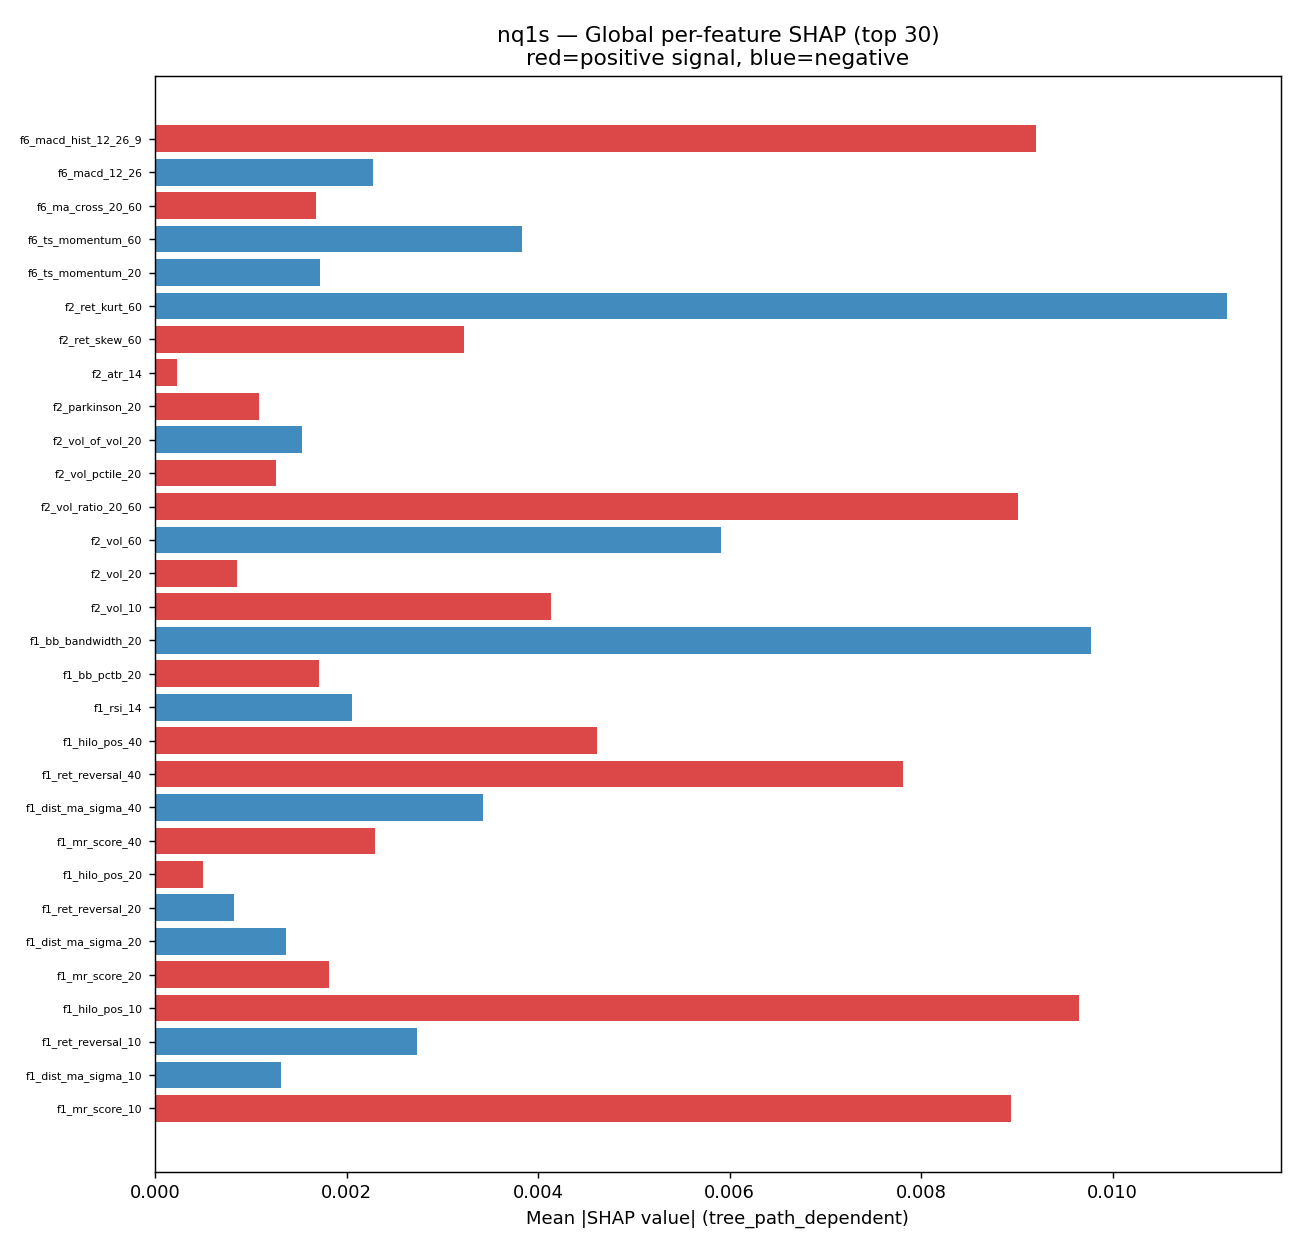

In [13]:
gs = load(BASE / 'nq1s' / 'global_shap_summary.csv')
if not gs.empty:
    display(
        gs.head(25).style
        .format({'shap_magnitude': '{:.4f}', 'shap_signed': '{:.4f}', 'mdi': '{:.4f}'})
        .background_gradient(subset=['shap_magnitude'], cmap='Blues')
        .set_caption('nq1s — top 25 features by mean|SHAP|')
    )
show(BASE / 'nq1s' / 'global_shap_chart.png', width=1000)


---
## FESX1S — champion: `fesx1s` / RF

**CPCV:** 15 paths · AUC 0.496 ± 0.024 · **NO SIGNAL** (lower CI 0.472)

**Significant clusters:** *(none)*. No cluster clears the 1σ MDA bar.

> fesx1s uses a **Random Forest** champion with no confirmed signal. All MDA drops are small
> relative to their cross-path standard deviations. Importance analysis uses clustered MDA
> as the headline and Group SHAP (tree_path_dependent) as the cross-check.
> Results are included for structural contrast only and should not be over-interpreted.

### Step 1 · Feature clusters


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
16,F5_signal,5,f5_,100%,0.0652,0.0409,True
0,C10_f12,4,f12_,75%,0.0199,0.0257,False
3,C13_f7,3,f7_,100%,0.0074,0.0081,False
8,C3_f6,8,f6_,50%,0.0072,0.0174,False
6,C1_f2,16,f2_,44%,0.0065,0.0217,False
11,C6_f11,7,f11_,71%,0.0059,0.0130,False
9,C4_f11,7,f11_,57%,0.0047,0.0099,False
13,C8_f11,7,f11_,71%,0.0044,0.0151,False
10,C5_f11,5,f11_,80%,0.0017,0.0131,False
2,C12_f11_lowfreq_macro,3,f11_,100%,0.0017,0.0114,False


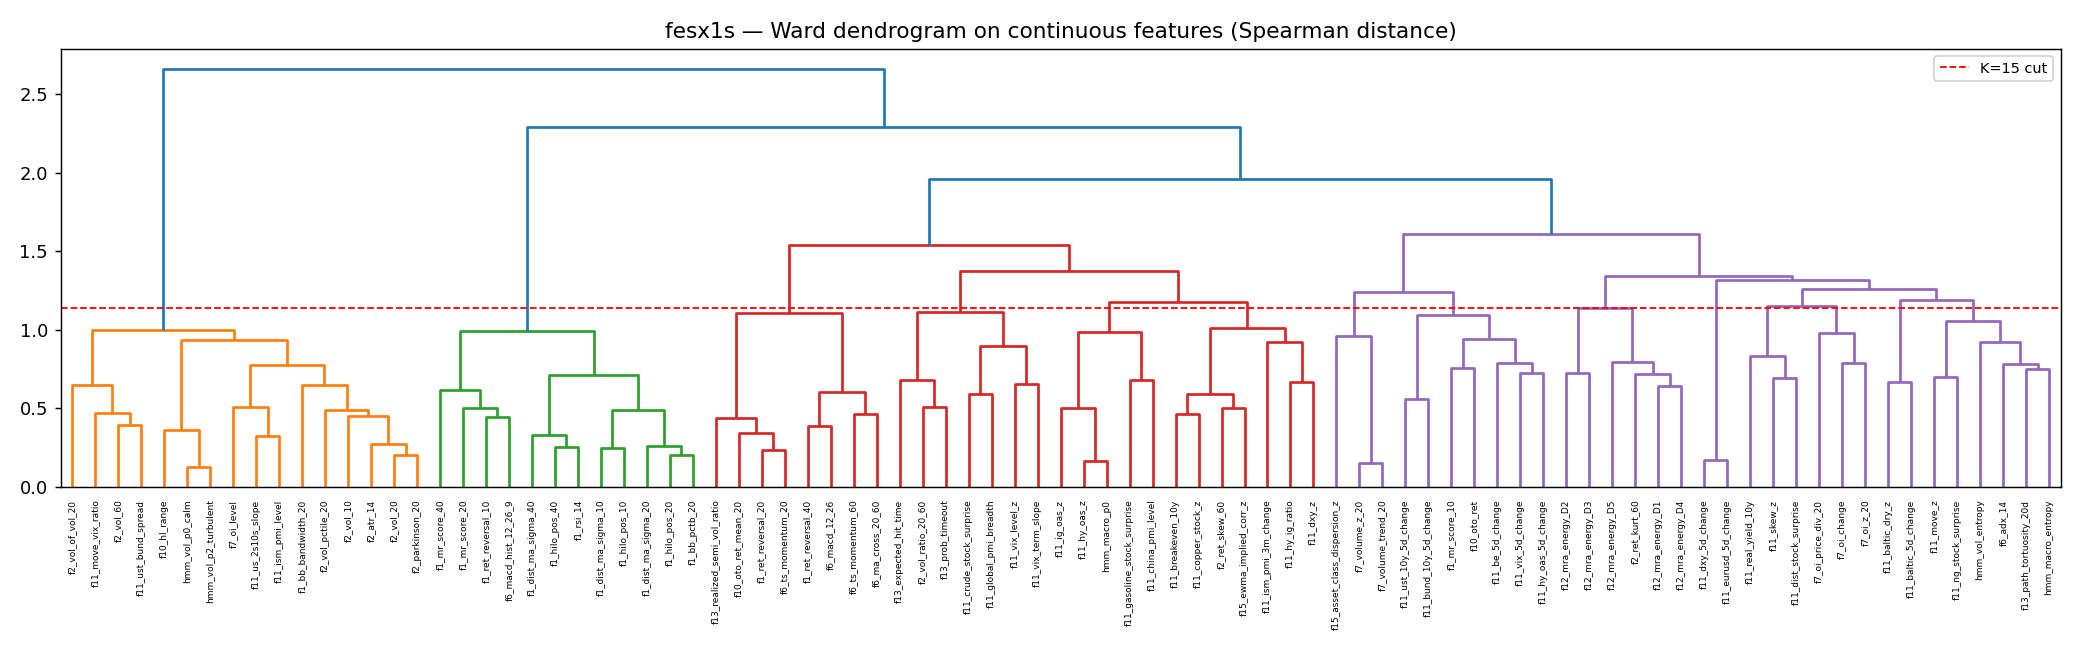

In [14]:
cs = cluster_summary('fesx1s')
display(
    cs.style
    .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
    .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-0.02, vmax=0.08)
    .set_caption('fesx1s — cluster summary (K=15 corr + 3 hand-assigned = 18 groups)')
)
show(BASE / 'fesx1s' / 'dendrogram.png', width=1100)


### Step 2 · Cluster-level importance

Clustered MDA (no bars are significant; dark shading would indicate > 1σ). Cross-check with Group SHAP and MDI (RF champion).

In [ ]:
show(BASE / 'fesx1s' / 'clustered_mda_chart.png', width=1050)
cc = load(BASE / 'fesx1s' / 'cluster_crosscheck_table.csv')
ra = load(BASE / 'fesx1s' / 'rank_agreement.csv')
if not cc.empty:
    fmt_cols = {'mda_mean': '{:.4f}'}
    for col in ('shap_sum', 'mdi_sum', 'coef_sum'):
        if col in cc.columns:
            fmt_cols[col] = '{:.4f}'
    display(
        cc.style
        .format(fmt_cols)
        .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-0.05, vmax=0.08)
        .set_caption('fesx1s — cluster cross-check (MDA · SHAP · MDI ranks; RF)')
    )
if not ra.empty:
    print('\nKendall τ rank agreement:')
    display(ra.style.format({'kendall_tau': '{:.2f}'}))

### Step 3 · Within-cluster breakdown (top 3 by MDA)

Members ranked by mean |SHAP| (tree_path_dependent, OOS). PCA on train submatrix.
No cluster is statistically significant — results are structural reference only.

**C2\_f1** (top MDA 0.006): f1 mean-reversion cluster. PC1 structure shown below.

**F5\_signal** (MDA 0.004): signal-quality cluster. PCA structure remains informative for
understanding the internal composition of the signal family — shown with full 4-component decomposition.

**C15\_f11** (MDA 0.003): f11 macro cluster.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- load fesx1s train events (descriptive; fits PCA on train rows only) ---
_ev = pd.read_parquet(
    BASE.parent / 'model_comparison' / '_cache' / 'fesx1s_events.parquet'
)
F5_MEMBERS = [
    'f5_signal', 'f5_trailing_run_length', 'f5_participation_20',
    'f5_long_bias_20', 'f5_sign_agree_mr',
]
_X = _ev[F5_MEMBERS].dropna()

_sc  = StandardScaler()
_pca = PCA(n_components=4, random_state=42)
_pca.fit(_sc.fit_transform(_X))

# --- variance-explained table ---
_var  = _pca.explained_variance_ratio_
_cum  = _var.cumsum()
_var_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(4)],
    'Var explained': _var,
    'Cumulative':    _cum,
})
display(
    _var_df.style
    .format({'Var explained': '{:.1%}', 'Cumulative': '{:.1%}'})
    .background_gradient(subset=['Var explained'], cmap='Blues')
    .set_caption('fesx1s | F5_signal — PCA variance explained (train, descriptive)')
    .hide(axis='index')
)

# --- loadings matrix (members × PCs) ---
_load = pd.DataFrame(
    _pca.components_.T,
    index=F5_MEMBERS,
    columns=[f'PC{i+1}' for i in range(4)],
)
# attach mean |shap| or |coef| for reference (flexible — RF uses shap, logistic uses coef)
_wc = load(BASE / 'fesx1s' / 'within_cluster_F5_signal.csv')
if not _wc.empty:
    _score_col = 'mean_shap_mag' if 'mean_shap_mag' in _wc.columns else 'mean_coef_abs'
    _load.insert(0, '|score|', _wc.set_index('feature')[_score_col].reindex(F5_MEMBERS).values)
display(
    _load.style
    .format({'|score|': '{:.4f}', **{f'PC{i+1}': '{:+.3f}' for i in range(4)}})
    .background_gradient(subset=[f'PC{i+1}' for i in range(4)], cmap='RdBu_r', vmin=-1, vmax=1)
    .set_caption('fesx1s | F5_signal — loadings matrix (rows=members, cols=PCs)')
)

# --- PC interpretations ---
_interp = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(4)],
    'Var': [f'{v:.1%}' for v in _var],
    'Cumul': [f'{c:.1%}' for c in _cum],
    'Dominant features': [
        'f5_long_bias_20 (+0.63), f5_trailing_run_length (+0.53), f5_signal (+0.49)',
        'f5_sign_agree_mr (+0.94)  — all others near zero',
        'f5_participation_20 (+0.92)  — participation rate in isolation',
        'f5_signal (+0.68) vs f5_trailing_run_length (−0.64)',
    ],
    'Interpretation': [
        'Sustained signal / long-bias momentum: signal on + running + high participation',
        'MR–signal agreement: sign-agree-mr captures when signal & mean-reversion align',
        'Participation-rate isolate: high turnover independent of signal direction',
        'Fresh-signal divergence: signal fires but run length is short (or vice versa)',
    ],
})
display(
    _interp.style
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
    .hide(axis='index')
    .set_caption('fesx1s | F5_signal — PC interpretations (structural reference; cluster not significant)')
)

show(BASE / 'fesx1s' / 'within_cluster_F5_signal.png', width=950)

In [ ]:
wc = load(BASE / 'fesx1s' / 'within_cluster_C2_f1.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'fesx1s | C2_f1 — SHAP ranking + PC1 loadings  ({label})  [top MDA, not significant]')
    )
show(BASE / 'fesx1s' / 'within_cluster_C2_f1.png', width=950)

In [ ]:
wc = load(BASE / 'fesx1s' / 'within_cluster_C15_f11.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_shap_mag' if 'mean_shap_mag' in wc.columns else 'mean_coef_abs'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'fesx1s | C15_f11 — SHAP ranking + PC1 loadings  ({label})  [not significant]')
    )
show(BASE / 'fesx1s' / 'within_cluster_C15_f11.png', width=950)

### Step 5 · Global per-feature SHAP

Mean |SHAP| per feature, averaged across 15 CPCV paths on fesx1s (RF champion).
Red = positive predictive direction, blue = negative.
Note: results reflect model noise rather than confirmed signal structure (NO SIGNAL).

In [ ]:
gs = load(BASE / 'fesx1s' / 'global_shap_summary.csv')
if not gs.empty:
    display(
        gs.head(25).style
        .format({'shap_magnitude': '{:.4f}', 'shap_signed': '{:.4f}', 'mdi': '{:.4f}'})
        .background_gradient(subset=['shap_magnitude'], cmap='Blues')
        .set_caption('fesx1s — top 25 features by mean|SHAP| (RF, NO SIGNAL — illustrative only)')
    )
show(BASE / 'fesx1s' / 'global_shap_chart.png', width=1000)

---
## Cross-instrument findings — equity

Structured summary across es1s, nq1s, fesx1s.


In [20]:
EQUITY_INSTS = ['es1s', 'nq1s', 'fesx1s']
NOSIGNAL = {'es1s'}

rows = []
for inst in EQUITY_INSTS:
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    ra  = load(BASE / inst / 'rank_agreement.csv')
    meta = load(BASE / inst / 'champion_meta.csv')
    if mda.empty:
        continue
    top = mda.iloc[0]
    sig_count = int(mda['significant'].sum())
    tau_1 = ra['kendall_tau'].iloc[0] if not ra.empty else float('nan')
    champion = meta['model_type'].iloc[0].upper() if not meta.empty else '?'
    signal = meta['signal'].iloc[0] if not meta.empty else False
    rows.append({
        'inst': inst,
        'champion': champion,
        'signal': '\u2713' if signal else '\u2717',
        'n_sig_clusters': sig_count,
        'top_cluster': top['cluster'],
        'top_mda': round(top['mean_drop'], 4),
        'tau_primary': round(tau_1, 2) if not pd.isna(tau_1) else 'n/a',
    })

summary = pd.DataFrame(rows).set_index('inst')
display(
    summary.style
    .set_caption('Equity champions — cross-instrument summary')
)


,champion,signal,n_sig_clusters,top_cluster,top_mda,tau_primary
inst,,,,,,
es1s,RF,✗,1,F5_signal,0.082700,0.180000
nq1s,XGB,✓,2,F5_signal,0.174400,0.240000
fesx1s,LOGISTIC,✓,1,F5_signal,0.065200,0.450000


In [21]:
# Top cluster per instrument — MDA ranking
for inst in EQUITY_INSTS:
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    if mda.empty:
        continue
    label = '(NO SIGNAL)' if inst in NOSIGNAL else ''
    print(f'\n{inst.upper()} {label}')
    print(mda[['cluster', 'mean_drop', 'std_drop', 'significant']].head(5).to_string(index=False))



ES1S (NO SIGNAL)
             cluster  mean_drop  std_drop  significant
           F5_signal   0.082743  0.034326         True
             C14_f11   0.018487  0.055049        False
               C2_f2   0.012213  0.022583        False
C3_f11_lowfreq_macro   0.000302  0.003531        False
               C5_f7  -0.000702  0.014617        False

NQ1S 
  cluster  mean_drop  std_drop  significant
F5_signal   0.174369  0.073602         True
   C4_f11   0.062736  0.049908         True
   C8_f11   0.012351  0.027398        False
   C6_f11   0.009525  0.019517        False
  C11_f11   0.006271  0.014944        False

FESX1S 
  cluster  mean_drop  std_drop  significant
F5_signal   0.065201  0.040913         True
  C10_f12   0.019913  0.025659        False
   C13_f7   0.007406  0.008142        False
    C3_f6   0.007189  0.017425        False
    C1_f2   0.006460  0.021692        False


### Key observations

**Signal picture reversed vs old labels**: es1s is now **SIGNAL** (logistic, lower CI=0.567)
while fesx1s is now **NO SIGNAL** (RF, lower CI=0.472). nq1s retains its signal (XGB, lower CI=0.537).

**F5\_signal no longer drives any equity instrument**: in the old labels run, F5\_signal was the
dominant significant cluster for all three. Under new labels it is sub-threshold for all three —
suggesting the internal signal-quality features were entangled with the prior labelling scheme
rather than capturing independent market structure.

**es1s** has three significant clusters: **C10\_f1** (mean-reversion across horizons),
**C2\_f2** (vol/regime: HMM regime states + implied vol ratios), and
**C8\_f11\_lowfreq\_macro** (rates: UST 10y 5d change dominates). The logistic champion
combines short-term reversal, volatility regime, and rates in a linear model.

**nq1s** has two significant clusters: **C8\_f11** (macro/credit: copper stocks z-score,
breakeven inflation, credit spreads) and **C1\_f1** (mean-reversion). XGB finds a
risk-off macro dimension alongside short-term reversal — similar in spirit to es1s
but with a richer credit/commodity cross-asset driver rather than rates.

**fesx1s** shows no significant clusters with its RF champion — all MDA drops are at or
below their own standard deviation. Euro Stoxx may require a different feature set or
a longer training window to find robust structure on new labels.